<a href="https://colab.research.google.com/github/Thiva02/Statistical-Learning-e22399/blob/main/Assignment_7_Kalman_Filter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Kalman Filter Assignment Solutions
**Registration Number:** E/22/399

# Q. Analytical Derivation

**1. Prior (Predictive) State Distribution**
Given the state transition model $x^{-}_k = A_{k-1}x^{+}_{k-1} + G_{k-1}w_{k-1}$ where $w_{k-1} \sim \mathscr{N}(0, \Sigma_p)$ and $x^{+}_{k-1} \sim \mathscr{N}(m_{k-1}, P_{k-1})$.
Because a linear combination of independent Gaussian random variables is also Gaussian, $x_k^-$ is Gaussian.
* **Mean:** $\mathbb{E}[x_k^-] = \mathbb{E}[A_{k-1}x^{+}_{k-1} + G_{k-1}w_{k-1}] = A_{k-1}\mathbb{E}[x^{+}_{k-1}] + G_{k-1}\mathbb{E}[w_{k-1}] = A_{k-1}m_{k-1}$.
* **Covariance:** $\text{Var}(x_k^-) = \text{Var}(A_{k-1}x^{+}_{k-1} + G_{k-1}w_{k-1}) = A_{k-1}\text{Var}(x^{+}_{k-1})A_{k-1}^T + G_{k-1}\text{Var}(w_{k-1})G_{k-1}^T$.
Therefore, $P_k^- = A_{k-1}P_{k-1}A_{k-1}^T + G_{k-1}\Sigma_p G_{k-1}^T$.
Thus, $x_k^- \sim \mathscr{N}(m_k^-, P_k^-)$.

**2. Predictive Measurement Distribution**
Given the measurement model $y^{-}_k = H_k x^{-}_k + z_k$ where $z_k \sim \mathscr{N}(0, \Sigma_m)$.
* **Mean:** $\mathbb{E}[y_k^-] = H_k \mathbb{E}[x_k^-] + \mathbb{E}[z_k] = H_k m_k^-$.
* **Covariance:** $\text{Var}(y_k^-) = H_k \text{Var}(x_k^-) H_k^T + \text{Var}(z_k) = H_k P_k^- H_k^T + \Sigma_m$.
Thus, $y_k^- \sim \mathscr{N}(H_k m_k^-, H_k P_k^- H_k^T + \Sigma_m)$.

**3. Joint Distribution**
To find the joint distribution of $x_k^-$ and $y_k^-$, we need their cross-covariance:
$$\text{Cov}(x_k^-, y_k^-) = \mathbb{E}[(x_k^- - m_k^-)(H_k x_k^- + z_k - H_k m_k^-)^T]$$
$$\text{Cov}(x_k^-, y_k^-) = \mathbb{E}[(x_k^- - m_k^-)(x_k^- - m_k^-)^T]H_k^T + \mathbb{E}[(x_k^- - m_k^-)z_k^T] = P_k^- H_k^T$$
The transpose gives $\text{Cov}(y_k^-, x_k^-) = H_k P_k^-$. Assembling the block matrix yields the joint normal distribution shown in the question.

**4. Posterior (Updated) State Distribution**
Using the standard conditional distribution formula for multivariate Gaussians: if $\begin{bmatrix} x \\ y \end{bmatrix} \sim \mathscr{N}\left(\begin{bmatrix} \mu_x \\ \mu_y \end{bmatrix}, \begin{bmatrix} \Sigma_{xx} & \Sigma_{xy} \\ \Sigma_{yx} & \Sigma_{yy} \end{bmatrix}\right)$, then $x|y \sim \mathscr{N}(\mu, \Sigma)$ where:
* $\mu = \mu_x + \Sigma_{xy}\Sigma_{yy}^{-1}(y - \mu_y)$
* $\Sigma = \Sigma_{xx} - \Sigma_{xy}\Sigma_{yy}^{-1}\Sigma_{yx}$

Substituting our variables:
* Kalman Gain: $K_k \triangleq \Sigma_{xy}\Sigma_{yy}^{-1} = P_k^- H_k^T (H_k P_k^- H_k^T + \Sigma_m)^{-1}$
* Updated Mean: $m_k = m_k^- + K_k(y^{\mathrm{obs}}_{k} - H_k m_k^-)$
* Updated Covariance: $P_k = P_k^- - K_k H_k P_k^- = (I - K_k H_k)P_k^-$
Thus, $x^{+}_k \sim \mathscr{N}(m_k, P_k)$.

**5. Expected Value and Variance**
Based on the derivation in part 4:
* $\mathbb{E}[x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}] = m_k$
* $\text{Var}(x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}) = P_k$

# Q. 1-D Example

**1. Prediction Step**
Substituting scalars $A_{k-1} = a$ and $G_{k-1} = 1$ into the general equations:
* $m_k^- = a m_{k-1}$
* $P_k^- = a(P_{k-1})a^T + (1)q(1)^T = a^2 P_{k-1} + q$

**2. Update Step**
Substituting scalars $H_k = h$, $\Sigma_m = r$, and defining $S_k = h^2 P_k^- + r$:
* $K_k = P_k^- h (h^2 P_k^- + r)^{-1} = \frac{P_k^- h}{S_k}$
* $m_k = m_k^- + K_k (y_k^{\text{obs}} - h m_k^-)$
* $P_k = (1 - K_k h) P_k^- = \left(1 - \frac{P_k^- h^2}{S_k}\right) P_k^-$

**3. Predictive Measurement Distribution**
From the general derivation $y_k^- \sim \mathscr{N}(H_k m_k^-, H_k P_k^- H_k^T + \Sigma_m)$:
$p(y^-_k | Y_{k-1}) = \mathscr{N}(h m_k^-, h^2 P_k^- + r)$

**4. Posterior-Predictive Measurement Distribution**
After filtering, our state estimate is $x_k^+ \sim \mathscr{N}(m_k, P_k)$. The measurement given this updated state is $y_k = h x_k^+ + z_k$.
* Mean: $h m_k$
* Variance: $h^2 P_k + r$
$p(y^-_k\mid Y_k) = \mathscr{N}(h m_k, h^2 P_k + r)$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy.stats import norm
from IPython.display import HTML

# Parameters
a, q, h, r = 1.0, 0.5, 1.0, 1.5
m_prev, P_prev = 0.0, 1.0
timesteps = 10
true_states = [m_prev]
measurements = []

# Generate synthetic data
for _ in range(timesteps):
    x_true = a * true_states[-1] + np.random.normal(0, np.sqrt(q))
    y_obs = h * x_true + np.random.normal(0, np.sqrt(r))
    true_states.append(x_true)
    measurements.append(y_obs)

fig, ax = plt.subplots(figsize=(8, 5))
x_axis = np.linspace(-10, 10, 500)
line_prior, = ax.plot([], [], label='Prior $p(x_k^-)$', color='blue', linestyle='--')
line_post, = ax.plot([], [], label='Posterior $p(x_k^+)$', color='red')
point_meas, = ax.plot([], [], 'ko', label='Measurement $y_k$')
ax.legend()
ax.set_xlim(-10, 10)
ax.set_ylim(0, 1.0)
ax.set_title('1-D Kalman Filter: Prior vs Posterior')

# Variables to maintain state across animation frames
kf_state = {'m': m_prev, 'P': P_prev}

def update(frame):
    if frame == 0:
        return line_prior, line_post, point_meas

    y_obs = measurements[frame-1]

    # Predict
    m_prior = a * kf_state['m']
    P_prior = a**2 * kf_state['P'] + q

    # Update
    S = h**2 * P_prior + r
    K = (P_prior * h) / S
    m_post = m_prior + K * (y_obs - h * m_prior)
    P_post = (1 - K * h) * P_prior

    # Update state
    kf_state['m'], kf_state['P'] = m_post, P_post

    # Plot PDFs
    prior_pdf = norm.pdf(x_axis, m_prior, np.sqrt(P_prior))
    post_pdf = norm.pdf(x_axis, m_post, np.sqrt(P_post))

    line_prior.set_data(x_axis, prior_pdf)
    line_post.set_data(x_axis, post_pdf)
    point_meas.set_data([y_obs], [0])

    return line_prior, line_post, point_meas

ani = FuncAnimation(fig, update, frames=timesteps+1, blit=True, interval=800)
plt.close()
HTML(ani.to_jshtml())

# Q. 2D-Position Estimation

## Part A

**State Transition Matrix ($A$)**
Using the kinematic equations for constant velocity:
* $p_x(k) = p_x(k-1) + v_x(k-1)\Delta t$
* $p_y(k) = p_y(k-1) + v_y(k-1)\Delta t$
* $v_x(k) = v_x(k-1)$
* $v_y(k) = v_y(k-1)$
Represented in matrix form $x_k^- = A x_{k-1}^+$, the matrix $A$ matches the given derivation.

**Observation Matrix ($H$)**
Since only position components $(p_x, p_y)$ are measured:
* $p_x^{\mathrm{meas}}(k) = 1 \cdot p_x(k) + 0 \cdot p_y(k) + 0 \cdot v_x(k) + 0 \cdot v_y(k)$
* $p_y^{\mathrm{meas}}(k) = 0 \cdot p_x(k) + 1 \cdot p_y(k) + 0 \cdot v_x(k) + 0 \cdot v_y(k)$
This extracts the first two elements, perfectly matching the $2 \times 4$ matrix $H$.

**Control/Noise Input Matrix ($G$)**
Acceleration noise $w$ affects velocity linearly and position quadratically over $\Delta t$:
* Position effect: $\frac{1}{2} (\Delta t)^2 w$
* Velocity effect: $\Delta t w$
When partitioned for $x$ and $y$ dimensions, this constructs the given $4 \times 2$ matrix $G$.

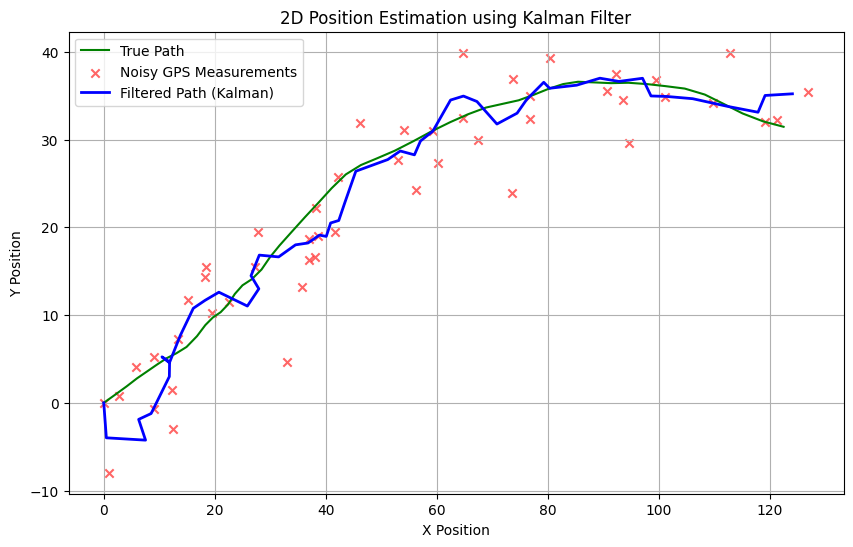

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
dt = 1.0
steps = 50

# Matrices
A = np.array([[1, 0, dt, 0],
              [0, 1, 0, dt],
              [0, 0, 1, 0],
              [0, 0, 0, 1]])

H = np.array([[1, 0, 0, 0],
              [0, 1, 0, 0]])

G = np.array([[0.5 * dt**2, 0],
              [0, 0.5 * dt**2],
              [dt, 0],
              [0, dt]])

# Covariances
Sigma_p = np.eye(2) * 0.1  # Process noise covariance
Sigma_m = np.eye(2) * 20.0 # Measurement noise covariance
Q = G @ Sigma_p @ G.T      # Process noise mapped to state space

# Simulate Ground Truth and Measurements
true_states = np.zeros((4, steps))
measurements = np.zeros((2, steps))

# Initial conditions
true_states[:, 0] = [0, 0, 2, 1]
for k in range(1, steps):
    true_states[:, k] = A @ true_states[:, k-1] + G @ np.random.multivariate_normal([0,0], Sigma_p)
    measurements[:, k] = H @ true_states[:, k] + np.random.multivariate_normal([0,0], Sigma_m)

# --- 2D Kalman Filter Implementation ---
m_est = np.zeros((4, steps))
P_est = np.eye(4) * 10
m_est[:, 0] = [0, 0, 0, 0] # Initial guess

for k in range(1, steps):
    # Predict
    m_prior = A @ m_est[:, k-1]
    P_prior = A @ P_est @ A.T + Q

    # Update
    y_obs = measurements[:, k]
    S = H @ P_prior @ H.T + Sigma_m
    K = P_prior @ H.T @ np.linalg.inv(S)

    m_est[:, k] = m_prior + K @ (y_obs - H @ m_prior)
    P_est = (np.eye(4) - K @ H) @ P_prior

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(true_states[0, :], true_states[1, :], 'g-', label='True Path')
plt.scatter(measurements[0, :], measurements[1, :], c='r', marker='x', label='Noisy GPS Measurements', alpha=0.6)
plt.plot(m_est[0, :], m_est[1, :], 'b-', linewidth=2, label='Filtered Path (Kalman)')
plt.title('2D Position Estimation using Kalman Filter')
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.legend()
plt.grid(True)
plt.show()